# Drivers 02 — Beach slope (CoastSat) + nearshore slope (Bruun pipeline)
Beach-face slope from CoastSat `csv_run7` (560 nzd sites), ERODIBILITY +
satellite trend from `transects_extended.geojson` (≤250 m nearest joins), and
nearshore `tanbeta` + closure depth keyed directly on `Unique_ID` from the
Bruun-rule CSV. Face slope covers sandy CoastSat coast only — coverage is
reported per region.

In [1]:
import pandas as pd
from drivers import common

In [2]:
import pandas as pd
from drivers import common

path = common.DRIVER_DATA / "d02_slope.parquet"
if not path.exists():
    from drivers.d02_slope import build
    df = build()
else:
    df = pd.read_parquet(path)
    print(f"loaded cached {path.name}: {len(df):,} rows")
df.head()

loaded cached d02_slope.parquet: 228,538 rows


,UniqueID,beach_slope_face,beach_slope_lb,beach_slope_ub,slope_dist_m,erodibility,coastsat_trend,coastsat_beach_slope,coastsat_dist_m,tanbeta_nearshore,closure_depth_m
0,203054437032,NaN,NaN,NaN,69290.473910,None,NaN,NaN,9270.475115,NaN,NaN
1,203054438164,NaN,NaN,NaN,69281.235016,None,NaN,NaN,9273.125789,NaN,NaN
2,203054439252,NaN,NaN,NaN,69271.868269,None,NaN,NaN,9274.820083,NaN,NaN
3,203054440300,NaN,NaN,NaN,69262.348250,None,NaN,NaN,9275.367160,NaN,NaN
4,203054441325,NaN,NaN,NaN,69252.718908,None,NaN,NaN,9275.099260,NaN,NaN


In [3]:
df.describe(include='all').T.head(40)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UniqueID,228538.0,NaN,NaN,NaN,139300979226.829895,48710893827.675819,100000185990.0,100422347904.25,100584280354.0,200240849080.75,203057476049.0
beach_slope_face,163897.0,NaN,NaN,NaN,0.076498,0.037791,0.01,0.045,0.065,0.095,0.195
beach_slope_lb,163897.0,NaN,NaN,NaN,0.066538,0.030035,0.01,0.0433,0.0595,0.0839,0.1702
beach_slope_ub,163897.0,NaN,NaN,NaN,0.089941,0.047551,0.0103,0.0518,0.0767,0.1155,0.2
slope_dist_m,228538.0,NaN,NaN,NaN,5496.788908,14509.848493,0.417621,125.618978,153.618919,549.228497,78157.354596
erodibility,9517,1,Hidden,9517,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coastsat_trend,167912.0,NaN,NaN,NaN,0.161787,1.534343,-27.063121,-0.333074,0.116338,0.553494,21.922141
coastsat_beach_slope,167912.0,NaN,NaN,NaN,0.075366,0.043906,0.01,0.04,0.065,0.095,0.2
coastsat_dist_m,228538.0,NaN,NaN,NaN,2325.690976,6723.492538,0.107781,102.600083,133.524705,309.650892,52084.255788
tanbeta_nearshore,190375.0,NaN,NaN,NaN,0.012532,0.012904,0.001006,0.00593,0.009647,0.014944,0.329721


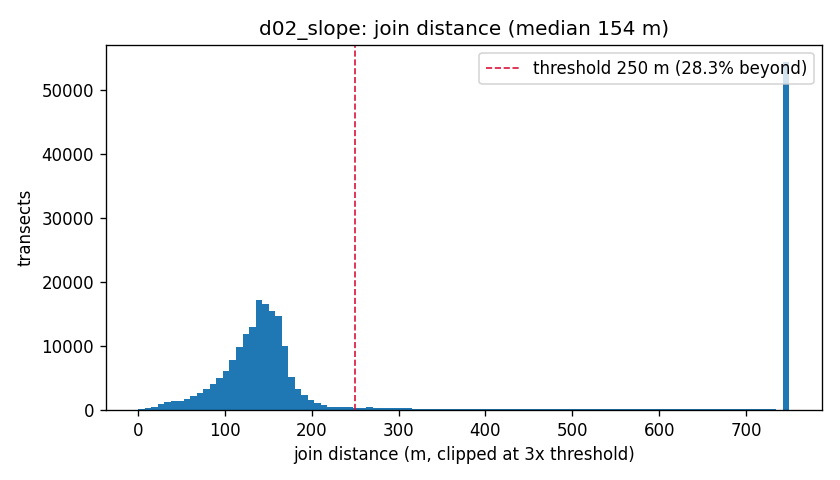

In [4]:
from IPython.display import Image, display
from drivers.common import QA_DIR
p = QA_DIR / 'd02_slope_join_dist.png'
display(Image(str(p), width=760)) if p.exists() else print('missing d02_slope_join_dist.png')